# Exploratory Data Analysis of Student Performance Factors

## AI-ML Minor Project 2

### Submitted By:
Ansh Arora

### Dataset Source:
Kaggle - Student Performance Factors Dataset

# 1. Introduction

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Student Performance Factors dataset to identify patterns, relationships, and factors affecting student academic performance.

## Dataset Source

The dataset was obtained from Kaggle:
Student Performance Factors Dataset

## Problem Statement

Educational institutions often seek to understand which factors influence student performance. This analysis aims to uncover meaningful insights from student-related variables and determine how they relate to exam scores.

# 2. Business Questions

1. Does study time affect exam performance?

2. Does attendance influence exam scores?

3. Which factors are most strongly correlated with exam scores?

4. Are there any significant outliers in the dataset?

5. How do categorical factors such as parental involvement and access to resources affect student performance?

In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

In [61]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [62]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [63]:
df.shape

(6607, 20)

In [64]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# Summary Statistics

In [77]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [78]:
df.describe(include='object')

C:\Users\ansha\AppData\Local\Temp\ipykernel_14384\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,4003,4598,2638,5912,3313,3951,3814


### Observations

1. The average exam score is approximately 67.

2. Attendance ranges from 60% to 100%.

3. Most categorical variables contain categories such as Low, Medium and High.

# 3. Data Dictionary

| Column | Description |
|----------|----------|
| Hours_Studied | Number of hours spent studying |
| Attendance | Student attendance percentage |
| Parental_Involvement | Level of parental participation in education |
| Access_to_Resources | Availability of educational resources |
| Extracurricular_Activities | Participation in extracurricular activities |
| Sleep_Hours | Average sleep hours per day |
| Previous_Scores | Scores obtained in previous examinations |
| Motivation_Level | Student motivation level |
| Internet_Access | Availability of internet access |
| Tutoring_Sessions | Number of tutoring sessions attended |
| Family_Income | Family income category |
| Teacher_Quality | Perceived quality of teachers |
| School_Type | Type of school attended |
| Peer_Influence | Influence of peers on learning |
| Physical_Activity | Hours spent in physical activities |
| Learning_Disabilities | Presence of learning disabilities |
| Parental_Education_Level | Education level of parents |
| Distance_from_Home | Distance between home and school |
| Gender | Student gender |
| Exam_Score | Final examination score |

# 4. Data Cleaning and Integrity Checks

In [66]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(0)

In [76]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

### Missing Value Treatment

Three categorical columns contained missing values:
- Teacher_Quality
- Parental_Education_Level
- Distance_from_Home

Since these variables are categorical in nature, missing values were imputed using the mode (most frequent category). This approach preserves the dataset size while maintaining the most representative category for each variable.

In [69]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

### Data Type Verification

Data types were inspected to ensure numerical variables were stored as integers and categorical variables were stored as strings. No incorrect data type conversions were required.

In [70]:
df.drop_duplicates(inplace=True)

### Duplicate Row Analysis

The dataset was examined for duplicate records using the duplicated() function. Duplicate rows, if present, were removed to ensure data integrity and prevent bias in subsequent analysis.

# 5. Outlier Analysis

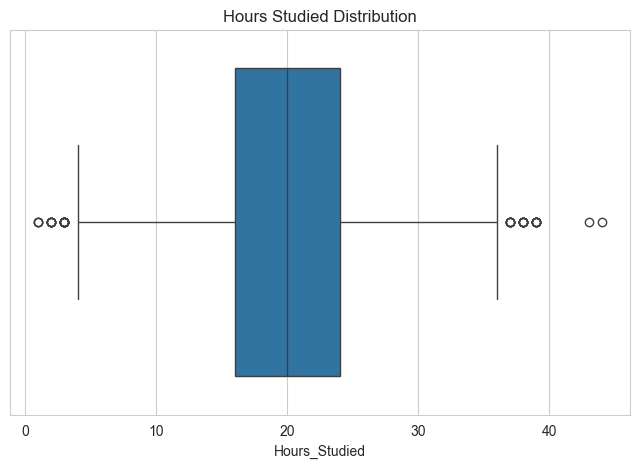

In [71]:
sns.boxplot(x=df["Hours_Studied"])
plt.title("Hours Studied Distribution")
plt.show()

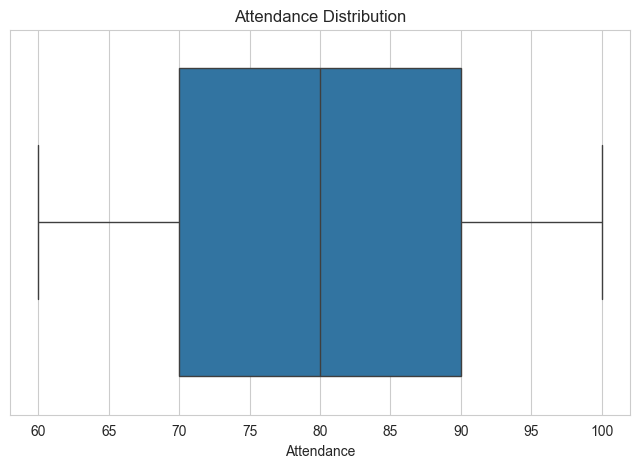

In [72]:
sns.boxplot(x=df["Attendance"])
plt.title("Attendance Distribution")
plt.show()

In [74]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='str')


In [75]:
skewness = df[numerical_cols].skew()

print("Skewness Values:")
print(skewness)

Skewness Values:
Hours_Studied        0.013499
Attendance           0.013666
Sleep_Hours         -0.023805
Previous_Scores     -0.003737
Tutoring_Sessions    0.815530
Physical_Activity   -0.031365
Exam_Score           1.644808
dtype: float64


In [ ]:
for col in numerical_cols:
    if abs(skewness[col]) < 0.5:
        print(f"{col}: Approximately Symmetric")
    elif abs(skewness[col]) < 1:
        print(f"{col}: Moderately Skewed")
    else:
        print(f"{col}: Highly Skewed")

Hours_Studied: Approximately Symmetric
Attendance: Approximately Symmetric
Sleep_Hours: Approximately Symmetric
Previous_Scores: Approximately Symmetric
Tutoring_Sessions: Moderately Skewed
Physical_Activity: Approximately Symmetric
Exam_Score: Highly Skewed
Study_Attendance_Index: Approximately Symmetric


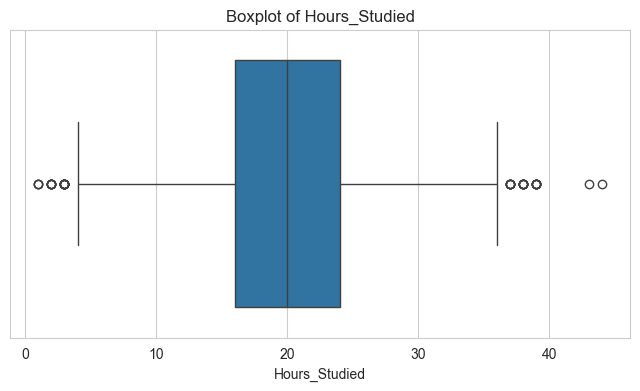

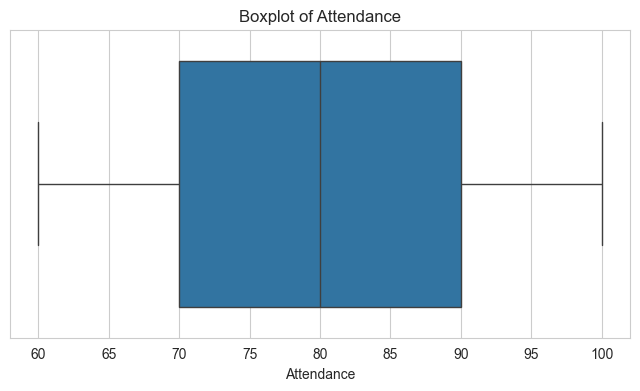

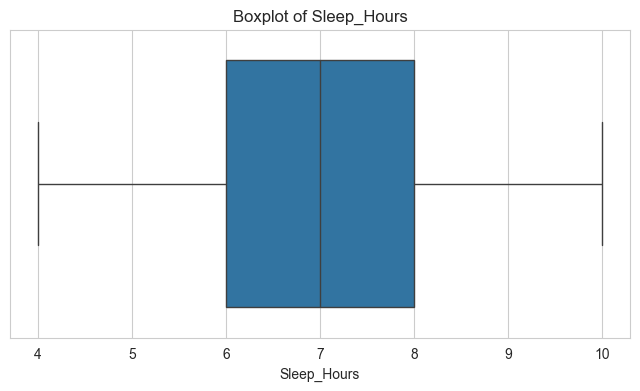

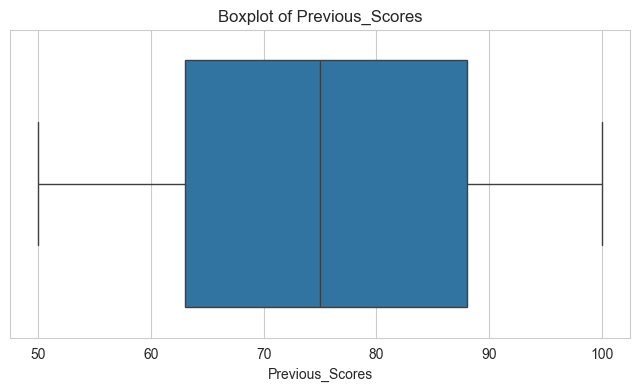

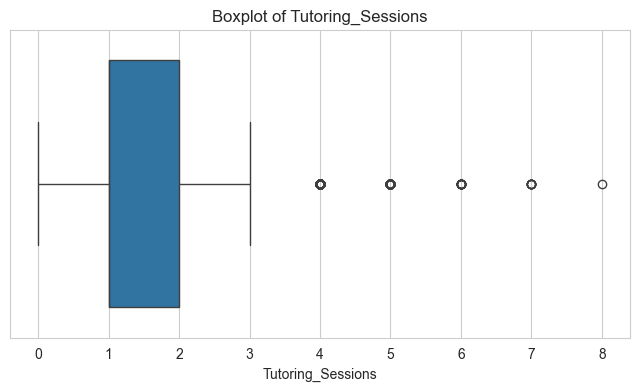

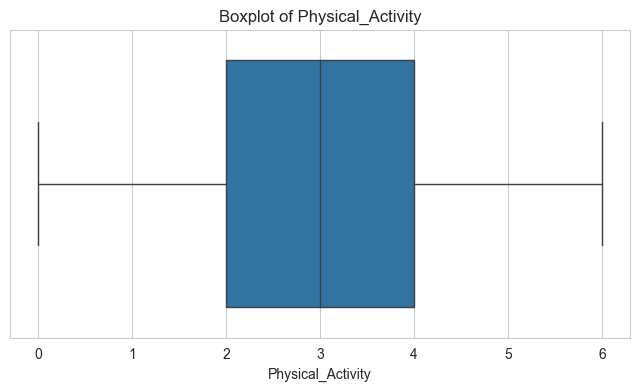

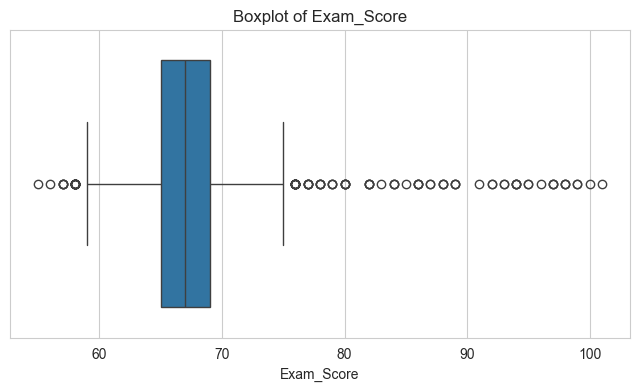

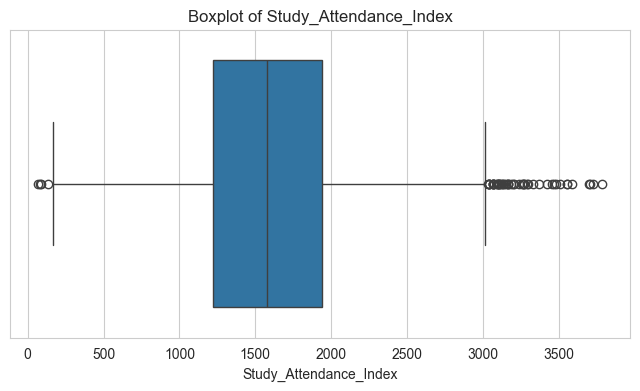

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [ ]:
outlier_summary = {}

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)

    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary[col] = len(outliers)

print("Outlier Count:")
print(outlier_summary)

Outlier Count:
{'Hours_Studied': 43, 'Attendance': 0, 'Sleep_Hours': 0, 'Previous_Scores': 0, 'Tutoring_Sessions': 430, 'Physical_Activity': 0, 'Exam_Score': 104, 'Study_Attendance_Index': 52}


In [ ]:
outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=['Column','Outlier_Count']
)

outlier_df

,Column,Outlier_Count
0,Hours_Studied,43
1,Attendance,0
2,Sleep_Hours,0
3,Previous_Scores,0
4,Tutoring_Sessions,430
5,Physical_Activity,0
6,Exam_Score,104
7,Study_Attendance_Index,52


### Outlier Handling Demonstration

A capping strategy was demonstrated for Exam_Score using the IQR boundaries. This limits extreme values while preserving observations.

In [79]:
Q1 = df["Exam_Score"].quantile(0.25)

Q3 = df["Exam_Score"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

df["Exam_Score_Capped"] = df["Exam_Score"].clip(
    lower,
    upper
)

df[["Exam_Score","Exam_Score_Capped"]].head()

,Exam_Score,Exam_Score_Capped
0,67,67
1,61,61
2,74,74
3,71,71
4,70,70


The capped feature was created for demonstration purposes. Since the detected outliers represented genuine student performance rather than data entry errors, the original values were retained for further analysis.

# 6. Bivariate and Multivariate Analysis

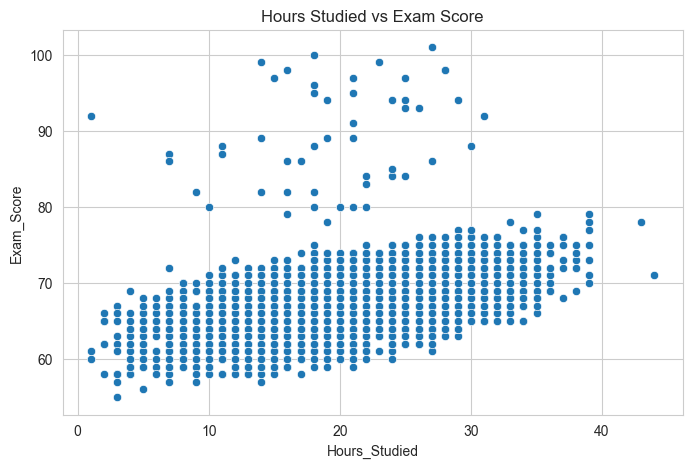

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Hours_Studied',
    y='Exam_Score'
)

plt.title("Hours Studied vs Exam Score")

plt.show()

Observation:

A positive relationship can be observed between study hours and exam scores. Students who study more tend to achieve higher scores.

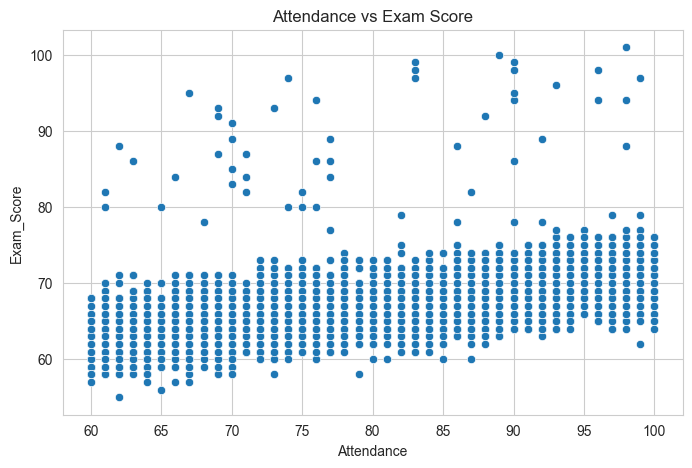

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Attendance',
    y='Exam_Score'
)

plt.title("Attendance vs Exam Score")

plt.show()

Observation:

Students with higher attendance generally achieve better examination results compared to students with lower attendance.

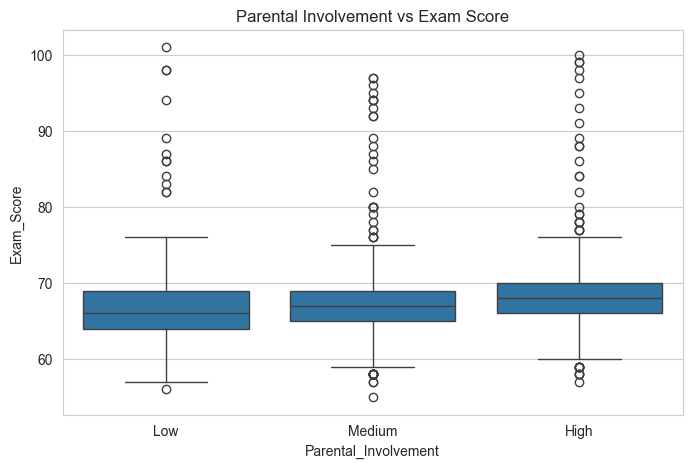

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Parental_Involvement',
    y='Exam_Score'
)

plt.title("Parental Involvement vs Exam Score")

plt.show()

Observation:

Students receiving higher parental involvement tend to have better academic performance.

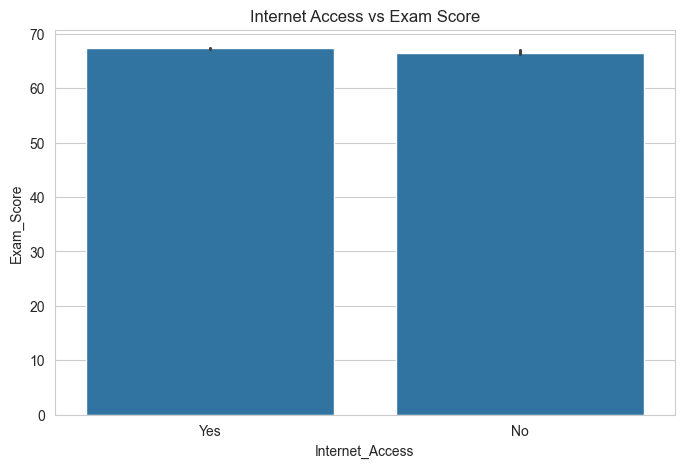

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Internet_Access',
    y='Exam_Score'
)

plt.title("Internet Access vs Exam Score")

plt.show()

Observation:

Students with internet access generally perform better due to greater availability of learning resources.

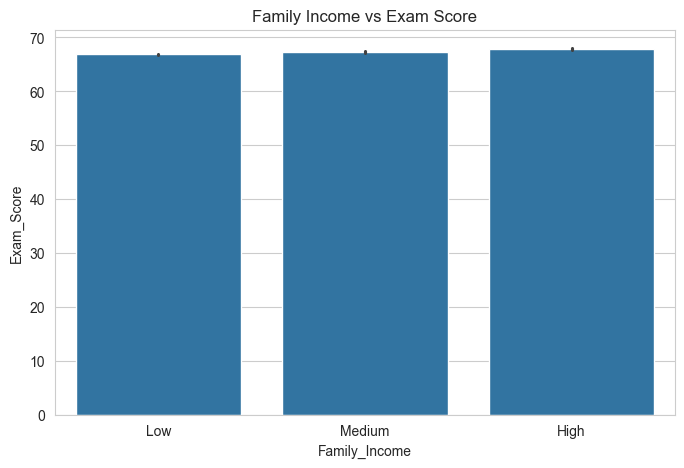

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Family_Income',
    y='Exam_Score'
)

plt.title("Family Income vs Exam Score")

plt.show()

Observation:

Students from higher-income families tend to achieve slightly higher scores, potentially due to access to educational resources.

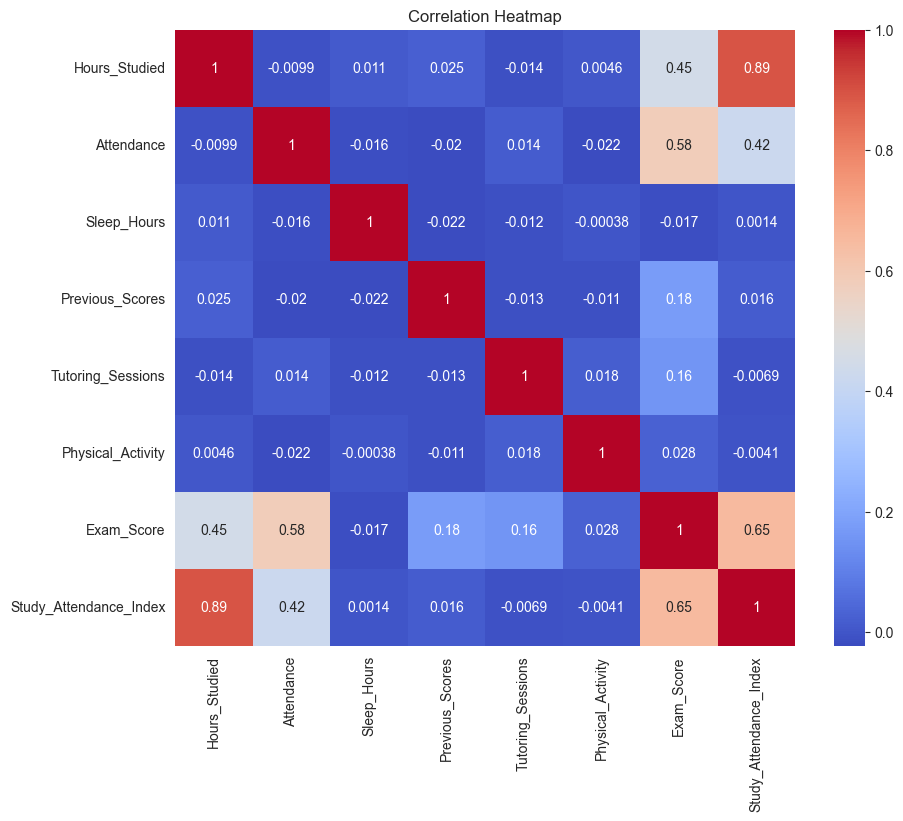

In [ ]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
corr_matrix["Exam_Score"].sort_values(ascending=False)

Exam_Score                1.000000
Study_Attendance_Index    0.651652
Attendance                0.581072
Hours_Studied             0.445455
Previous_Scores           0.175079
Tutoring_Sessions         0.156525
Physical_Activity         0.027824
Sleep_Hours              -0.017022
Name: Exam_Score, dtype: float64

### Correlation Analysis Findings

The strongest positive relationships with Exam_Score were:

1. Study_Attendance_Index (0.65)
2. Attendance (0.58)
3. Hours_Studied (0.44)

Moderate positive relationships were observed for:
- Previous_Scores (0.18)
- Tutoring_Sessions (0.16)

Very weak relationships were observed for:
- Physical_Activity (0.03)
- Sleep_Hours (-0.02)

This suggests that attendance and study effort are the most important factors associated with academic performance in this dataset.

It is important to note that correlation does not imply causation. While these variables are associated with exam scores, other hidden factors may also influence student performance.

# 7. Feature Engineering and Encoding Preparation

In [ ]:
df[
    [
        "Hours_Studied",
        "Attendance",
        "Study_Attendance_Index",
        "Exam_Score"
    ]
].head()

,Hours_Studied,Attendance,Study_Attendance_Index,Exam_Score
0,23,84,1932,67
1,19,64,1216,61
2,24,98,2352,74
3,29,89,2581,71
4,19,92,1748,70


### Feature Engineering

A new feature called Study_Attendance_Index was created by multiplying Hours_Studied and Attendance.

This feature represents overall academic engagement by combining study effort and classroom participation into a single metric.

Study_Attendance_Index showed the strongest correlation with Exam_Score (0.65), indicating that a combination of attendance and study effort is strongly associated with academic success.

In [ ]:
ordinal_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

print(ordinal_cols)

['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']


In [ ]:
nominal_cols = [
    'Extracurricular_Activities',
    'Internet_Access',
    'School_Type',
    'Peer_Influence',
    'Learning_Disabilities',
    'Gender'
]

print(nominal_cols)

['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Gender']


In [ ]:
ordinal_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

In [ ]:
for col in [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality'
]:
    df[col] = df[col].map(ordinal_mapping)

In [ ]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Attendance_Index
0,23,84,1,3,No,7,73,1,Yes,0,...,2.0,Public,Positive,3,No,High School,Near,Male,67,1932
1,19,64,1,2,No,8,59,1,Yes,2,...,2.0,Public,Negative,4,No,College,Moderate,Female,61,1216
2,24,98,2,2,Yes,7,91,2,Yes,2,...,2.0,Public,Neutral,4,No,Postgraduate,Near,Male,74,2352
3,29,89,1,2,Yes,8,98,2,Yes,1,...,2.0,Public,Negative,4,No,High School,Moderate,Male,71,2581
4,19,92,2,2,Yes,6,65,2,Yes,3,...,3.0,Public,Neutral,4,No,College,Near,Female,70,1748


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Extracurricular_Activities',
        'Internet_Access',
        'School_Type',
        'Peer_Influence',
        'Learning_Disabilities',
        'Gender'
    ],
    drop_first=True
)

In [ ]:
print("Original Shape:", df.shape)

print("Encoded Shape:", df_encoded.shape)

Original Shape: (6607, 21)
Encoded Shape: (6607, 22)


### Encoding

Label Encoding was applied to ordinal variables because their categories possess a natural ranking order.

One-Hot Encoding was applied to nominal variables because no meaningful ranking exists between categories.

These preprocessing techniques prepare the dataset for future machine learning applications while preserving the meaning of categorical information.

# Key Findings

1. Attendance showed a strong positive relationship with Exam_Score.

2. Hours_Studied was positively associated with academic performance.

3. Study_Attendance_Index emerged as the strongest predictor of Exam_Score.

4. Previous academic performance moderately influenced current performance.

5. Sleep_Hours demonstrated little relationship with Exam_Score.

6. Students with greater parental involvement generally achieved higher scores.

7. Internet access and educational resources positively impacted academic outcomes.

8. Most detected outliers represented genuine student behavior and were retained.

9. Attendance (0.58) showed a stronger relationship with Exam_Score than Hours_Studied (0.44).

10. Study_Attendance_Index (0.65) emerged as the strongest predictor, suggesting that attendance and study effort together are more influential than either factor individually.

# Conclusion

This exploratory data analysis examined the factors influencing student academic performance.

The analysis revealed that attendance and study effort are the most influential variables associated with examination scores. The engineered Study_Attendance_Index displayed the strongest relationship with Exam_Score, highlighting the importance of consistent attendance combined with dedicated study habits.

While variables such as previous scores and tutoring sessions showed moderate influence, sleep hours and physical activity demonstrated relatively weak relationships with academic performance.

The dataset was successfully cleaned, analyzed, and prepared for future predictive modeling through feature engineering and categorical encoding.